# Group 14 A4 Formative Task

## Project Title
Green Space Distribution Equity in Greater Melbourne

## Research Question
How evenly is open space distributed across SA2 areas in Greater Melbourne?

In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

In [4]:
sa2 = gpd.read_file(
    "boundary/study_area.gpkg",
)

open_space = gpd.read_file(
    "open_space/open_space_melbourne.gpkg"
)

print(sa2.shape)
print(open_space.shape)
sa2.head()

(360, 18)
(38639, 22)


,id,SA2_CODE_2021,SA2_NAME_2021,CHANGE_FLAG_2021,CHANGE_LABEL_2021,SA3_CODE_2021,SA3_NAME_2021,SA4_CODE_2021,SA4_NAME_2021,GCCSA_CODE_2021,GCCSA_NAME_2021,STATE_CODE_2021,STATE_NAME_2021,AUS_CODE_2021,AUS_NAME_2021,AREA_ALBERS_SQKM,ASGS_LOCI_URI_2021,geometry
0,1081,213051362,Hoppers Crossing - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,7.0114,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.6654 -37.8701, 144.66529 -..."
1,1083,213051368,Werribee - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,114.0332,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.73479 -37.94361, 144.73479..."
2,1086,213051467,Werribee - East,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,7.7569,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.64116 -37.88193, 144.64109..."
3,1087,213051468,Werribee - West,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,127.6631,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.59729 -37.94211, 144.59733..."
4,1088,213051579,Manor Lakes - Quandong,1,New,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,72.0339,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.51648 -37.87412, 144.54997..."


360


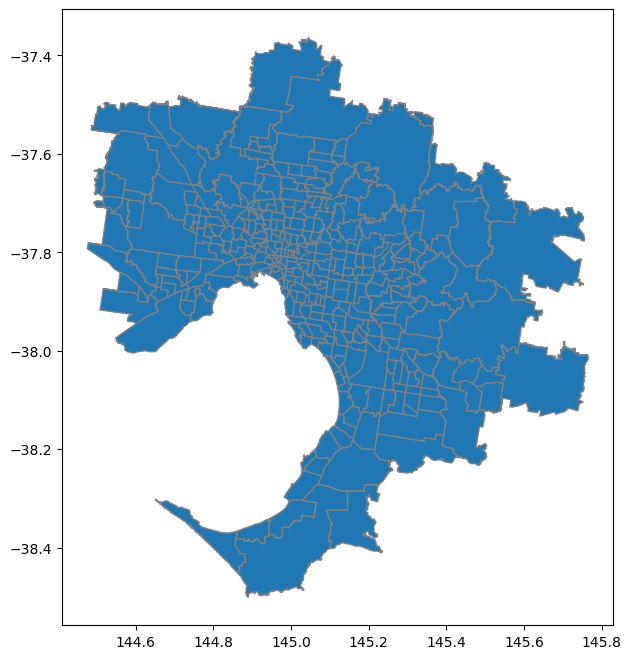

In [5]:
melb = sa2.copy()

print(len(melb))

melb.plot(
    figsize=(8,8),
    edgecolor="grey"
)

plt.show()

In [6]:
melb=melb.to_crs(7855)
open_space=open_space.to_crs(7855)

melb["sa2_area"]=melb.geometry.area

overlay=gpd.overlay(
    open_space,
    melb[
        [
            "SA2_CODE_2021",
            "geometry"
        ]
    ],
    how="intersection"
)

overlay["open_area"]=overlay.area

summary=(
    overlay
    .groupby(
        "SA2_CODE_2021"
    )
    ["open_area"]
    .sum()
    .reset_index()
)

melb=melb.merge(
    summary,
    on="SA2_CODE_2021",
    how="left"
)

melb["open_area"]=(
    melb["open_area"]
    .fillna(0)
)

melb["coverage"]=(
    melb["open_area"]
    /
    melb["sa2_area"]
)*100

melb.head()

,id,SA2_CODE_2021,SA2_NAME_2021,CHANGE_FLAG_2021,CHANGE_LABEL_2021,SA3_CODE_2021,SA3_NAME_2021,SA4_CODE_2021,SA4_NAME_2021,GCCSA_CODE_2021,...,STATE_CODE_2021,STATE_NAME_2021,AUS_CODE_2021,AUS_NAME_2021,AREA_ALBERS_SQKM,ASGS_LOCI_URI_2021,geometry,sa2_area,open_area,coverage
0,1081,213051362,Hoppers Crossing - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,...,2,Victoria,AUS,Australia,7.0114,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((294653.085 5806028.552, 294645...",7.012411e+06,8.268239e+05,11.790865
1,1083,213051368,Werribee - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,...,2,Victoria,AUS,Australia,114.0332,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((300955.332 5798020.917, 300955...",1.140616e+08,7.032759e+07,61.657575
2,1086,213051467,Werribee - East,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,...,2,Victoria,AUS,Australia,7.7569,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((292554.398 5804662.406, 292548...",7.758551e+06,1.657223e+06,21.359952
3,1087,213051468,Werribee - West,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,...,2,Victoria,AUS,Australia,127.6631,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((288867.598 5797885.557, 288870...",5.991604e+07,2.559582e+07,42.719471
4,1088,213051579,Manor Lakes - Quandong,1,New,21305,Wyndham,213,Melbourne - West,2GMEL,...,2,Victoria,AUS,Australia,72.0339,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((281564.588 5805244.323, 284521...",1.493557e+07,6.630091e+06,44.391269


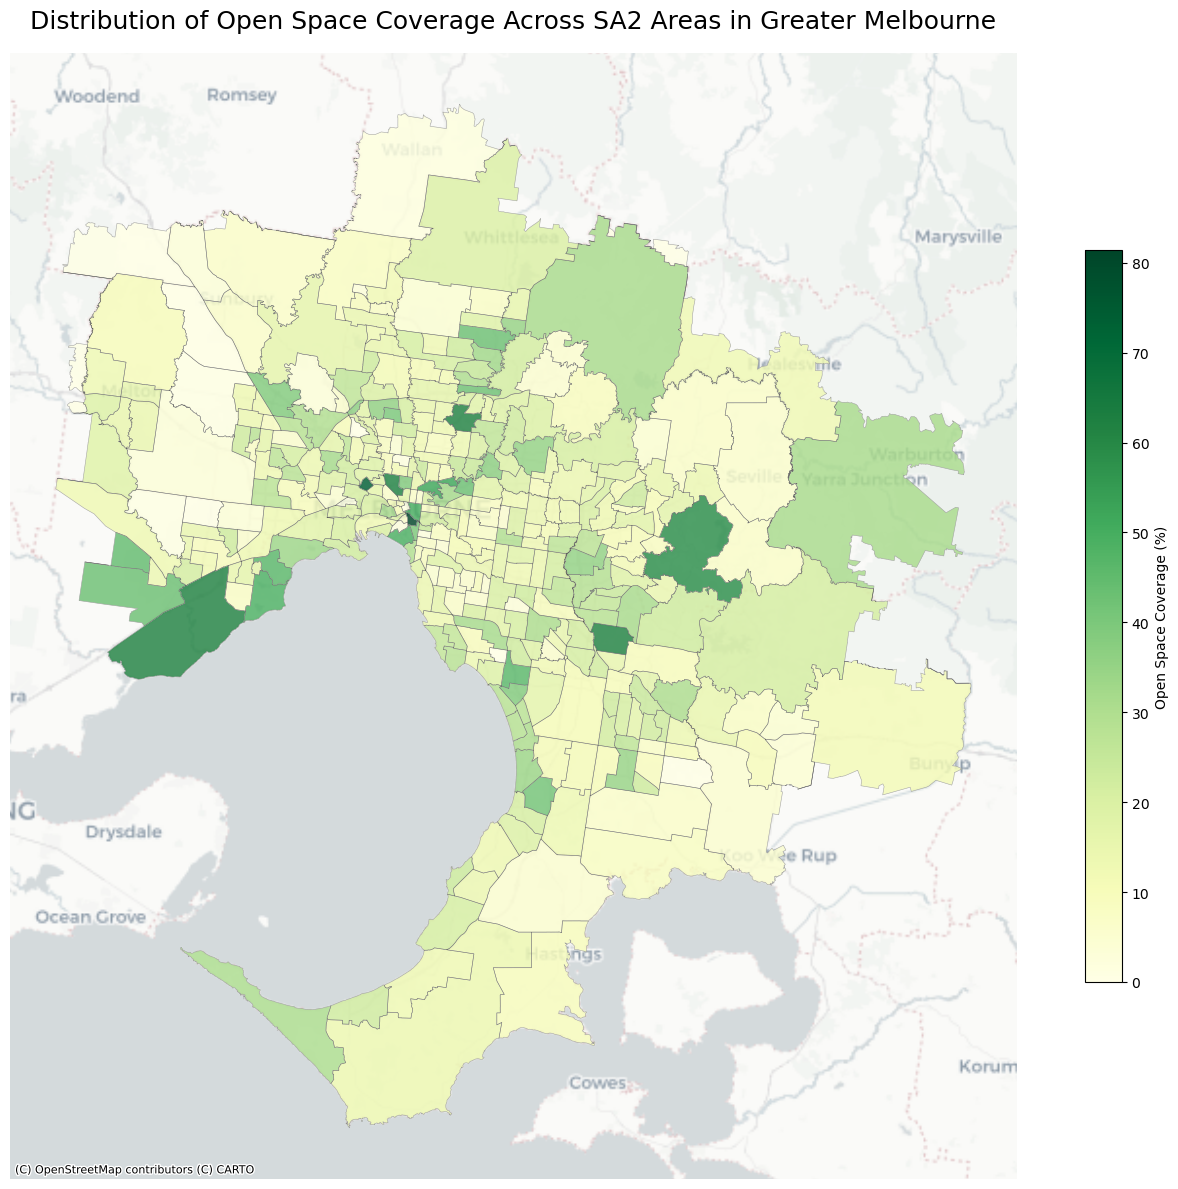

In [7]:
melb=melb.to_crs(3857)

fig,ax=plt.subplots(
    figsize=(14,12)
)

melb.plot(
    column="coverage",
    cmap="YlGn",
    linewidth=0.35,
    edgecolor="white",
    alpha=0.82,
    legend=True,
    ax=ax,
    legend_kwds={
        "label":"Open Space Coverage (%)",
        "shrink":0.65
    }
)

melb.boundary.plot(
    ax=ax,
    linewidth=0.4,
    color="black",
    alpha=0.35
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

ax.set_title(
    "Distribution of Open Space Coverage Across SA2 Areas in Greater Melbourne",
    fontsize=18,
    pad=18
)

ax.axis("off")

plt.tight_layout()

plt.savefig(
    "green_space_formative.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretation

This map presents the spatial distribution of open space coverage across SA2 areas in Greater Melbourne. The results indicate substantial variation in the proportion of land allocated to open space throughout the metropolitan region.

Higher open space coverage appears in several outer metropolitan and peripheral areas, while many inner and middle-ring suburbs display lower proportions. This pattern may be associated with differences in development intensity, land use allocation, and the availability of large public reserves.

In relation to the research question, the findings suggest that green space is not evenly distributed across Greater Melbourne. Although this map focuses only on spatial coverage, it provides an initial indication of potential inequality in environmental amenity and accessibility. Future analysis may incorporate population data to evaluate green space per capita and better assess distribution equity.

## Declaration

I acknowledge the use of ChatGpt to help me debug my code for data analysis and generate images for this assessment.

I used it to help visualise the distribution of green space in the Melbourne metropolitan area.

A full record of prompts and outputs is available upon request.

## Research Question 2
To what extent does open space coverage influence urban heat intensity across Greater Melbourne, and what spatial patterns can be identified in the relationship between green infrastructure and urban heat?

### 1. Introduction
Urban heat is one of the most significant environmental challenges facing contemporary cities. Green infrastructure, particularly public open space, has been widely recognised as an effective strategy for mitigating urban heat. This analysis investigates the relationship between open space coverage and urban heat intensity across Greater Melbourne using spatial analytical techniques.

### 2. ESDA

In [88]:
import geopandas as gpd
import pandas as pd

heat = gpd.read_file("urban_heat/urban_heat.gpkg")
heat_sa2 = (heat.groupby("SA2_NAME16")["UHI18_M"].mean().reset_index())

q2 = melb.merge(
    heat_sa2,
    left_on="SA2_NAME_2021",
    right_on="SA2_NAME16",
    how="inner"
)

q2.head()

,id,SA2_CODE_2021,SA2_NAME_2021,CHANGE_FLAG_2021,CHANGE_LABEL_2021,SA3_CODE_2021,SA3_NAME_2021,SA4_CODE_2021,SA4_NAME_2021,GCCSA_CODE_2021,...,AUS_CODE_2021,AUS_NAME_2021,AREA_ALBERS_SQKM,ASGS_LOCI_URI_2021,geometry,sa2_area,open_area,coverage,SA2_NAME16,UHI18_M
0,1081,213051362,Hoppers Crossing - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,...,AUS,Australia,7.0114,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((16104078.525 -4561091.453, 161...",7.012411e+06,8.268239e+05,11.790865,Hoppers Crossing - South,8.385504
1,1083,213051368,Werribee - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,...,AUS,Australia,114.0332,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((16111802.697 -4571463.547, 161...",1.140616e+08,7.032759e+07,61.657575,Werribee - South,6.900058
2,1086,213051467,Werribee - East,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,...,AUS,Australia,7.7569,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((16101380.797 -4562759.439, 161...",7.758551e+06,1.657223e+06,21.359952,Werribee - East,7.630220
3,1087,213051468,Werribee - West,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,...,AUS,Australia,127.6631,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((16096496.805 -4571250.532, 160...",5.991604e+07,2.559582e+07,42.719471,Werribee - West,8.069294
4,1112,214021383,Point Nepean,0,No change,21402,Mornington Peninsula,214,Mornington Peninsula,2GMEL,...,AUS,Australia,67.1876,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((16125943.474 -4643363.334, 161...",6.719391e+07,2.059349e+07,30.647845,Point Nepean,3.073223


In [90]:
# Export Q2 result for Part D

q2_export = q2[
    [
        "SA2_CODE_2021",
        "SA2_NAME_2021",
        "coverage",
        "open_area",
        "UHI18_M",
        "geometry"
    ]
].copy()

q2_export["SA2_CODE_2021"] = q2_export["SA2_CODE_2021"].astype(str)

q2_export = q2_export.rename(
    columns={
        "SA2_CODE_2021": "sa2_code",
        "SA2_NAME_2021": "sa2_name"
    }
)

q2_export.to_file("q2_green_heat.gpkg", driver="GPKG")

#### Summary Statistics 

In [15]:
q2[["coverage", "UHI18_M"]].describe()

,coverage,UHI18_M
count,257.000000,257.000000
mean,18.383258,8.266447
std,12.299425,1.828274
min,0.000000,0.029429
25%,10.025083,7.517670
50%,16.070639,8.398132
75%,22.591331,9.373265
max,74.079449,11.716022


From the output, we can see that the distribution of green space in Melbourne is severely polarized, with over 75% of suburbs having a green coverage rate of less than 22.59%, and only a very few marginal eco-zones possessing exceptionally high green coverage. The urban heat island effect is a systemic crisis, with over 75% of the area experiencing an average temperature range exceeding 7.52°C, meaning the vast majority of residents face extremely high heat exposure risks during the summer.

#### Open Space Histogram 

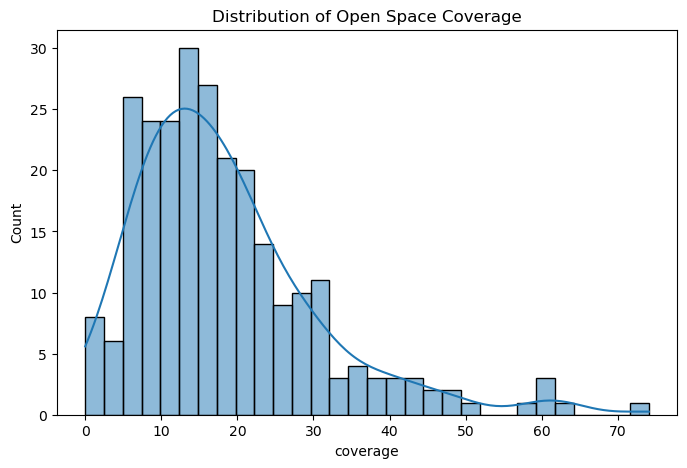

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    q2["coverage"],
    bins=30,
    kde=True
)

plt.title("Distribution of Open Space Coverage")

plt.show()

The histogram of open space coverage reveals a highly right-skewed (positively skewed) distribution across the SA2 statistical units in Greater Melbourne.

The vast majority of suburban areas have relatively low green cover, specifically between 5% and 20%. The peak distribution occurs around 12% to 15%, indicating that green infrastructure in most Melbourne suburbs is generally poor. The distribution curve exhibits a long right tail, with coverage reaching over 70%. These extreme values ​​represent a few exceptional low-density fringe suburbs, or areas close to major protected areas and national parks, such as the Yarra Range or Dandenong Mountain.

#### Urban Heat Histogram

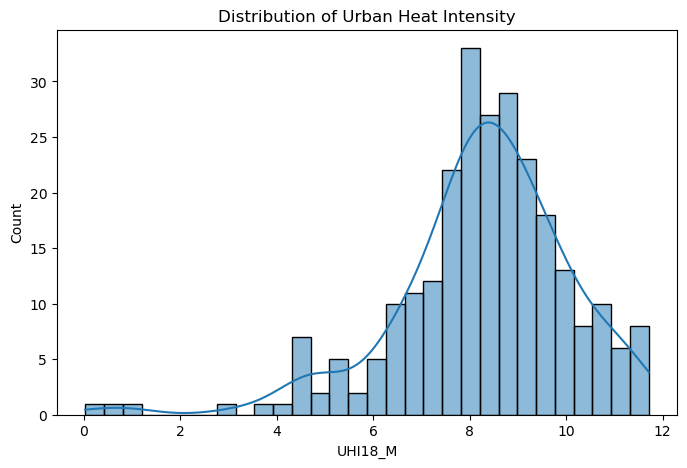

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    q2["UHI18_M"],
    bins=30,
    kde=True
)

plt.title("Distribution of Urban Heat Intensity")

plt.show()

The histogram for Urban Heat Island Intensity (UHI18_M) displays a distinct left-skewed (negatively skewed) distribution, which stands in sharp contrast to the green space distribution.

The data are primarily concentrated in the high-intensity range, with major peaks between 7.5°C and 9.5°C. This indicates that during the summer peak season, heat accumulation and urban warming are systemic and pervasive environmental pressures affecting most SA2 residential units in Melbourne.

A relatively flat, low-frequency distribution appears in the low-value areas below 5°C, approaching 0°C. These low-heat island intensity areas spatially correspond highly to the high-green-coverage polygons in the previous figure, representing "cool island" buffer zones within the city, demonstrating the effective blocking and absorption of solar radiation by the natural canopy.

The inverse skewness between these two figures visually validates the team's hypothesis: areas with severe deficiencies in green space infrastructure correspond to the dominant high-temperature disaster clusters in the statistical charts.

#### Pivot Table

In [24]:
# Top 10 Hottest SA2
pivot_heat = q2[["SA2_NAME_2021", "UHI18_M"]].sort_values("UHI18_M", ascending=False).head(10)
pivot_heat

,SA2_NAME_2021,UHI18_M
43,Burnside Heights,11.716022
208,Cranbourne,11.665816
40,Sydenham,11.574009
100,Cairnlea,11.566726
245,Narre Warren - North East,11.466223
7,Melton West,11.451552
37,Delahey,11.409298
111,Burnside,11.348166
124,Moorabbin Airport,11.302094
28,Essendon Airport,11.219677


The 10 hottest areas in Melbourne are highly concentrated in the west, such as Burnside Heights, Sydenham, Cairnlea, Melton West, and Delahey, as well as the southeast, such as Cranbourne and Narre Warren. These areas are under extreme pressure from the urban heat island. Many of the western areas on the list are rapidly developing, peripheral suburbs with relatively low incomes for their residents, providing direct evidence for Question 3 to further explore whether vulnerable groups are suffering the adverse effects of extreme microclimates.

In [26]:
# Divide the coverage into 5 groups
q2["coverage_group"] = pd.qcut(q2["coverage"], 5, labels=["Low", "medium_low", "Medium", "medium_high", "High"])
# Calculate the average heat island effect for each group
pivot = pd.pivot_table(q2, values="UHI18_M", index="coverage_group", aggfunc="mean")
pivot

,UHI18_M
coverage_group,
Low,8.209160
medium_low,8.249160
Medium,8.365996
medium_high,8.143713
High,8.363429


Surprisingly, across all groups from low to high green coverage, the average heat island intensity remained at a relatively high level, ranging from approximately 8.14°C to 8.37°C, exhibiting a slight non-linear fluctuation rather than a simple linear decline. This suggests that the heat island effect in Greater Melbourne is a large-scale, regional climate phenomenon. While highly green areas can still provide shade and comfort for pedestrians, the table highlights the systemic nature of Melbourne's heatwave crisis. Simply adding green space in isolation in a suburb cannot completely eliminate the regional heat accumulation. This necessitates that future urban planning establish a networked green infrastructure, rather than scattered, isolated parks.

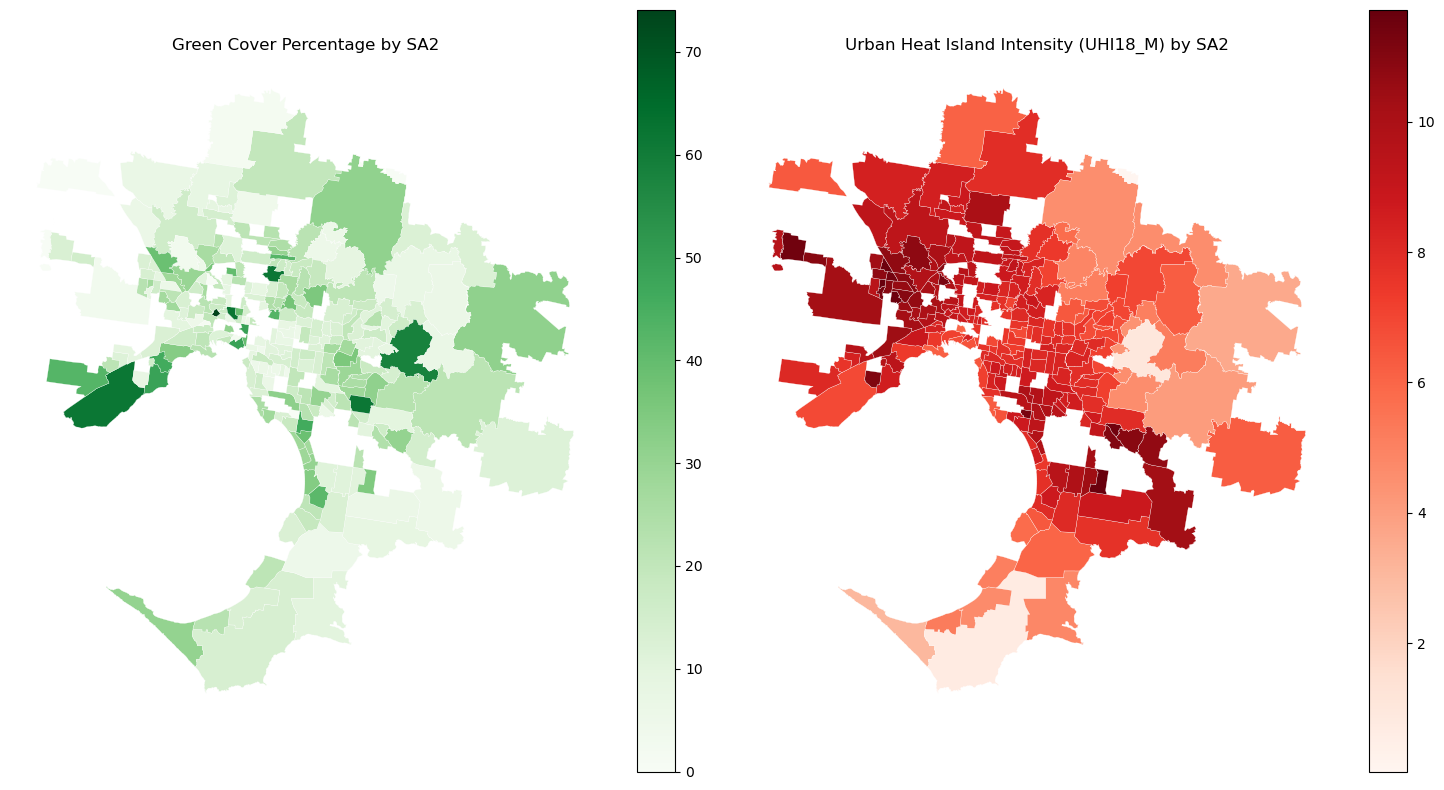

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))
q2.plot(column='coverage', cmap='Greens', legend=True, ax=ax1, edgecolor='white', linewidth=0.2)
ax1.set_title('Green Cover Percentage by SA2')
ax1.set_axis_off()
q2.plot(column='UHI18_M', cmap='Reds', legend=True, ax=ax2, edgecolor='white', linewidth=0.2)
ax2.set_title('Urban Heat Island Intensity (UHI18_M) by SA2')
ax2.set_axis_off()
plt.tight_layout()
plt.show()

The left map (green space coverage map) reveals a severe spatial imbalance in Melbourne's urban vegetation infrastructure. High-density forests and parks (dark green areas) are concentrated in the far east residential areas and the northeastern ecological protection zone, such as the Yarra Valley. In contrast, the western industrial and northern parts of Melbourne are largely undeveloped, with green coverage rates generally falling below the average of 20%.

The right map (urban heat island intensity map) presents a mirror image of the left map geographically. A systemic extreme heat island center (dark red area) with temperatures exceeding 8°C to 10°C overwhelmingly covers Melbourne's western suburbs and northern edges. These areas lack vegetation shade and have become severely affected by climate disasters.

### 3. Green Space and Urban Heat Correlation Analysis

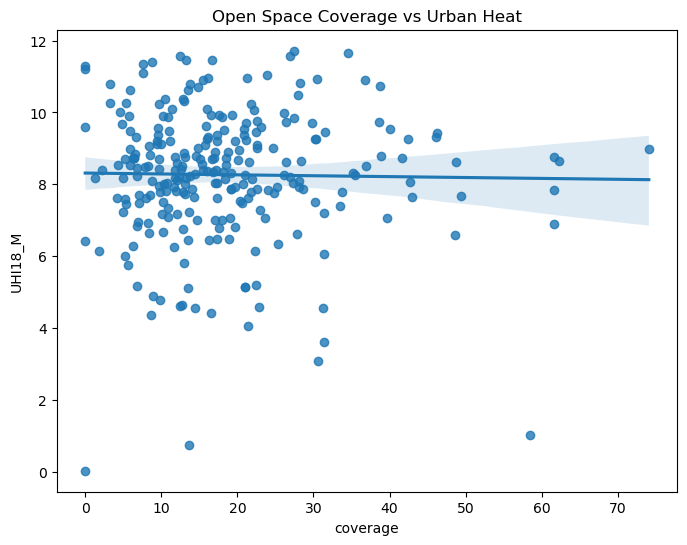

In [31]:
plt.figure(figsize=(8,6))

sns.regplot(
    x="coverage",
    y="UHI18_M",
    data=q2,
)

plt.title("Open Space Coverage vs Urban Heat")

plt.show()

The regression trend line between open space coverage and urban heat island intensity (UHI18_M) exhibits a nearly horizontal slope. This indicates that the direct linear correlation between the two is extremely weak at the global level across all SA2 statistical units in Melbourne. As green coverage exceeds 40%, the confidence interval (shaded area) on the right side of the chart widens significantly, meaning that within high green coverage areas, the dispersion and statistical uncertainty of data points increase substantially. In the densely populated 5% to 30% coverage range, even with slight increases in green coverage in some areas, the overall average heat island intensity remains high because it fails to reach the critical threshold for fundamentally altering the local thermal balance.

This weak linear trend does not mean that green spaces have no cooling effect; this is because the heat island effect in Greater Melbourne is a large-scale, regional, and complex atmospheric phenomenon. Large areas of hardened, impermeable surfaces, such as dense industrial buildings, form a massive heat-absorbing dome. During periods of extreme summer temperatures, this systemic accumulation of heat across regions often partially masks the localized cooling effect of isolated parks within a single SA2 area.

#### Pearson Correlation

In [75]:
from scipy.stats import pearsonr

r,p = pearsonr(q2["coverage"], q2["UHI18_M"])


print(r,p)

-0.01671832111368456 0.7896791960372168


The Pearson correlation coefficient $r$ is a statistical indicator used to measure the degree of linear correlation between two variables. 

Pearson correlation analysis showed that the correlation coefficient between open space coverage and urban heat island intensity in each SA2 unit of Greater Melbourne was $r = -0.0167$, with a significance test value of $p = 0.7897$. In mathematical statistics, since $r$ is extremely close to zero and $p$ is much greater than the critical threshold of 0.05, this clearly indicates that there is no statistically significant linear correlation between green space coverage and urban heat island intensity in the study area.

### 4. Moran's I
#### Global Moran's I

In [73]:
from libpysal.weights import Queen
from esda.moran import Moran

w = Queen.from_dataframe(q2, use_index=False)

w.transform = "r"

moran_uhi = Moran(q2["UHI18_M"], w)

print(moran_uhi.I)
print(moran_uhi.p_sim)

0.7529942825492286
0.001


Global Moran's I measures the spatial clustering of a single variable across the entire study area. An index close to 1 indicates a high degree of clustering of similar values, and the significance ($p < 0.05$) confirms that this clustering is a definite fact, not a random coincidence.

The Global Moran's I calculated for the urban heat island intensity (UHI18_M) is as high as $I = 0.7530$, and the significance value $p = 0.001$ is less than 0.05, rejecting the null hypothesis. This refutes the assumption of spatial random distribution and strongly demonstrates that the thermal environment of the Greater Melbourne area exhibits extremely strong positive spatial autocorrelation and geographical clustering characteristics.

#### Bivariate Moran's I

In [40]:
from esda.moran import Moran_BV

mbv = Moran_BV(q2["coverage"], q2["UHI18_M"], w)
print(mbv.I)
print(mbv.p_sim)

0.05337193333848847
0.067


Bivariate Moran's I is used to measure the spatial correlation between two different variables, assessing whether a local observation of one variable is significantly influenced by another variable in its surrounding neighborhood.

When conducting a cross-spatial association analysis between local green space coverage and the surrounding urban heat island (UHI) intensity, the Bivariate Moran's I appears to be extremely weak, and the $p$-value failed the significance test at 0.05. This insignificant result is precisely because Melbourne's high temperatures are overwhelmingly concentrated over large areas globally (with a Global Moran's I of 0.7530), meaning that during the hottest periods, the local cooling effect of green space in a single SA2 suburb is directly weakened by the hot winds released from the surrounding surface.

### 5. OLS Regression
According to the theoretical model, this section constructs an ordinary least squares (OLS) linear regression model to empirically test the linear hypothesis of $UHI = \beta_0 + \beta_1 Coverage$ across 257 SA2 spatial units in the Greater Melbourne area.

In [43]:
# !pip install --upgrade --user scipy statsmodels

In [44]:
import statsmodels.api as sm

X = sm.add_constant(q2["coverage"])

y = q2["UHI18_M"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                UHI18_M   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                   0.07129
Date:                Thu, 11 Jun 2026   Prob (F-statistic):              0.790
Time:                        18:21:02   Log-Likelihood:                -519.20
No. Observations:                 257   AIC:                             1042.
Df Residuals:                     255   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.3121      0.206     40.401      0.0

The statistical output reveals the following conclusions:

* $\beta_1 = -0.0025, p = 0.790$: The regression coefficient for the independent variable coverage is only -0.0025, meaning that in the model's extrapolation, for every $1%$ increase in green space coverage, the heat island intensity decreases by $0.0025^\circ\text{C}$. Its $p$-value of 0.790 is significantly greater than 0.05, indicating that the cooling coefficient from green space is not statistically significant.

* $\beta_0 = 8.3121^\circ\text{C}$: The intercept term of the model is $8.3121^\circ\text{C}$ and is significant ($p = 0.000$). This indicates that during periods of extreme heat, there may be a thermal dome in the Greater Melbourne area due to surface heat storage, resulting in an overall base temperature difference exceeding $8.3^\circ\text{C}$.

<Axes: >

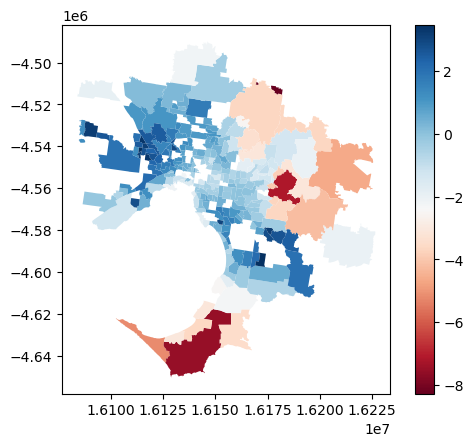

In [46]:
q2["residual"] = model.resid

q2.plot(
    column="residual",
    cmap="RdBu",
    legend=True
)

In [47]:
residual_moran = Moran(q2["residual"], w)

print(residual_moran.I, residual_moran.p_sim)

0.7548085724267387 0.001


The residual Moran's index is as high as $0.7548$ which is close to 1, and the $p$-value is $0.001$, which is significantly. This indicates that the model's prediction error is not due to random interference, but rather to a severe systematic and spatially clustered bias.

* Dark blue cluster (positive residual - model underestimation): The OLS model underestimates the heat island effect in western and northern Melbourne. This means that the actual temperature in these areas is much higher than the model predicts. This reveals that the model is missing key environmental variables, such as the large-scale, high-density hardened roofs of warehouses and industrial buildings in the west, and airport runways, which are accumulating heat and have been ignored by the model.

* Dark red cluster (negative residual - model overestimation): The model significantly overestimates temperatures in the inner city, coastal areas, and parts of the southeast. This means that these areas are actually quite cool. The model overestimates the heat because it ignores the geographical cooling effect of the ocean.

### 6. Conclusion and Limitation

This section investigated the relationship between open space coverage and urban heat intensity in Greater Melbourne. While conventional statistical methods did not reveal a significant linear relationship, spatial analysis showed that the urban heat island effect exhibits strong geographical clustering.

These findings underscore the importance of spatial planning approaches. The results indicate that Melbourne's urban heat island effect is primarily driven by regional-scale spatial processes, rather than solely by the influence of localised green space area. Green infrastructure remains an important adaptation strategy, but effective mitigation requires coordinated metropolitan planning that integrates green networks, urban design, and sustainable land use management.

**Limitations:**

1. The analysis was conducted at the SA2 level, which may have masked significant differences within suburban areas. When data is aggregated to relatively large spatial units, the localized cooling effects of parks and street trees may not be fully captured.

2. Open space coverage was used as a simplified indicator of the quality of green infrastructure. This dataset does not distinguish between different vegetation types, canopy density, tree height, irrigation conditions, or accessibility, all of which can influence cooling effects.

3. The OLS model includes only one explanatory variable. Residual analysis strongly suggests that future research should incorporate more environmental and urban variables, such as building density, industrial land, elevation, and distance from the coast.